In [18]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [19]:
training_data = datasets.FashionMNIST(
  root="data",
  train=True,
  download=True,
  transform=ToTensor()
)
test_data = datasets.FashionMNIST(
  root="data",
  train=False,
  download=True,
  transform=ToTensor()
)

In [20]:
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size)
test_dataloader = DataLoader(test_data, batch_size)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [27]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu = nn.Sequential(
      nn.Linear(28*28, 512),
      nn.ReLU(),
      nn.Linear(512, 512),
      nn.ReLU(),
      nn.Linear(512, 10)
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu(x)
    return logits


In [28]:
base_model = NeuralNetwork().to(device)
base_model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(base_model.parameters(), lr=0.01)

In [30]:
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


In [33]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0,0

  with torch.inference_mode():
    for X,y in dataloader:
      X,y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size

  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [36]:
epochs = 5

for t in range(epochs):
  print(f"Epoch {t+1}\n-------------------------------")
  train(train_dataloader, base_model, loss_fn, optimizer)
  test(test_dataloader, base_model, loss_fn)

print("Done!")

Epoch 1
-------------------------------
loss: 0.198240  [    0/60000]
loss: 0.474353  [ 6400/60000]
loss: 0.296627  [12800/60000]
loss: 0.390578  [19200/60000]
loss: 0.508023  [25600/60000]
loss: 0.537879  [32000/60000]
loss: 0.367592  [38400/60000]
loss: 0.471572  [44800/60000]
loss: 0.552128  [51200/60000]
loss: 0.678139  [57600/60000]
Test Error: 
 Accuracy: 82.5%, Avg loss: 0.479366 

Epoch 2
-------------------------------
loss: 0.308010  [    0/60000]
loss: 0.327352  [ 6400/60000]
loss: 0.309765  [12800/60000]
loss: 0.430410  [19200/60000]
loss: 0.589042  [25600/60000]
loss: 0.500443  [32000/60000]
loss: 0.378681  [38400/60000]
loss: 0.576393  [44800/60000]
loss: 0.469457  [51200/60000]
loss: 0.343576  [57600/60000]
Test Error: 
 Accuracy: 84.4%, Avg loss: 0.437901 

Epoch 3
-------------------------------
loss: 0.244370  [    0/60000]
loss: 0.333123  [ 6400/60000]
loss: 0.298144  [12800/60000]
loss: 0.441719  [19200/60000]
loss: 0.536651  [25600/60000]
loss: 0.421231  [32000/600

In [37]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [40]:
def predict_and_plot(model, dataloader):
  model.eval()
  with torch.inference_mode():
    X,y = next(iter(dataloader))
    X,y = X.to(device), y.to(device)
    pred = model(X).argmax(1)
    X,y, pred = X.cpu(), y.cpu(), pred.cpu()

    plt.imshow(X[1].squeeze(), cmap="gray")
    plt.title(f"Predicted: {class_names[pred[1]]}, Actual: {class_names[y[1]]}")
    plt.show()


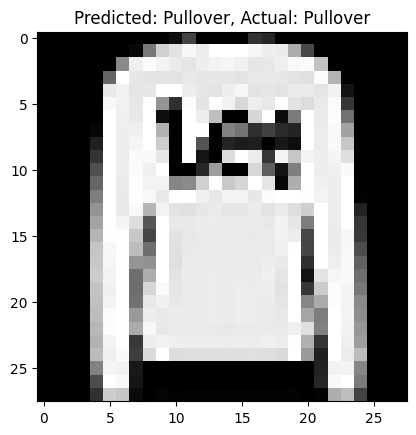

In [41]:
predict_and_plot(base_model, test_dataloader)